# Preprocessing + Model Training + Evaluation
---
## Preprocessing

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split

# ==== Configurations ====
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [27]:
df = pd.read_csv("../data/Medical Cost Personal Dataset - Regression.csv")

In [28]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Features with little to no contribution

- __sex:__ The sex bar chart showed only ∼2k difference for smokers and ∼0.5k for non-smokers. Compared to the 25k+ gap from smoking, sex is noise. It adds almost no predictive power.
- __region:__ Regional averages only range from 12.3k to 14.7k. That’s a 2.4k spread total. Smoking alone causes a 20k+ jump. Region might reflect small lifestyle or cost-of-living differences, but it’s weak.
- __children:__ The Age vs Charges colored by children showed all colors in every cost band. Having more kids nudges costs up slightly within each band, but it never pushed someone into a different tier. Weak effect.

## Dropping sex, region & children

In [30]:
df_nw = df.drop(columns=["sex", "region", "children"])

In [32]:
df_nw.head(3)

,age,bmi,smoker,charges
0,19,27.90,yes,16884.9240
1,18,33.77,no,1725.5523
2,28,33.00,no,4449.4620


## Data Split - Train & Test

In [33]:
X = df_nw[['age', 'bmi', 'smoker']]
Y = df_nw["charges"]

In [34]:
x_train, x_test,y_train, y_test = train_test_split(
    X, Y, random_state=42, 
    train_size=0.85, 
    shuffle=True,
)

In [35]:
X.shape, x_train.shape, x_test.shape

((1338, 3), (1137, 3), (201, 3))

## Feature Encoding

__Categorical Features:__ 
- smoker

## Feature Scaling

__Numerical Features:__ 
- age
- bmi

## Applying ColumnTransformer

In [36]:
transformer = ColumnTransformer(transformers=[
    ('t1',RobustScaler(),['age', 'bmi']),
    ('t2',OneHotEncoder(sparse=False,drop='first'),['smoker'])
],remainder='passthrough')

In [37]:
x_train_nw = pd.DataFrame(transformer.fit_transform(x_train))

x_test_nw = pd.DataFrame(transformer.transform(x_test))

## Model Training

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True
)

In [47]:
rf_model.fit(x_train_nw, y_train)

RandomForestRegressor(oob_score=True, random_state=42)

In [79]:
print("Out-of-Bag Score:", rf_model.oob_score_)

y_pred = rf_model.predict(x_test_nw)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", np.round(r2, 2))

N, p = x_test.shape
adj_r2 = 1-(((1-r2)*(N-1))/(N-p-1))
print("Adj. R-squared:", np.round(adj_r2, 2))

Out-of-Bag Score: 0.8043491009140201
Mean Squared Error: 26343303.974157523
R-squared: 0.83
Adj. R-squared: 0.82


## Compairing Visually

In [85]:
title = f"Adj. R2 score: {np.round(adj_r2, 2)}"

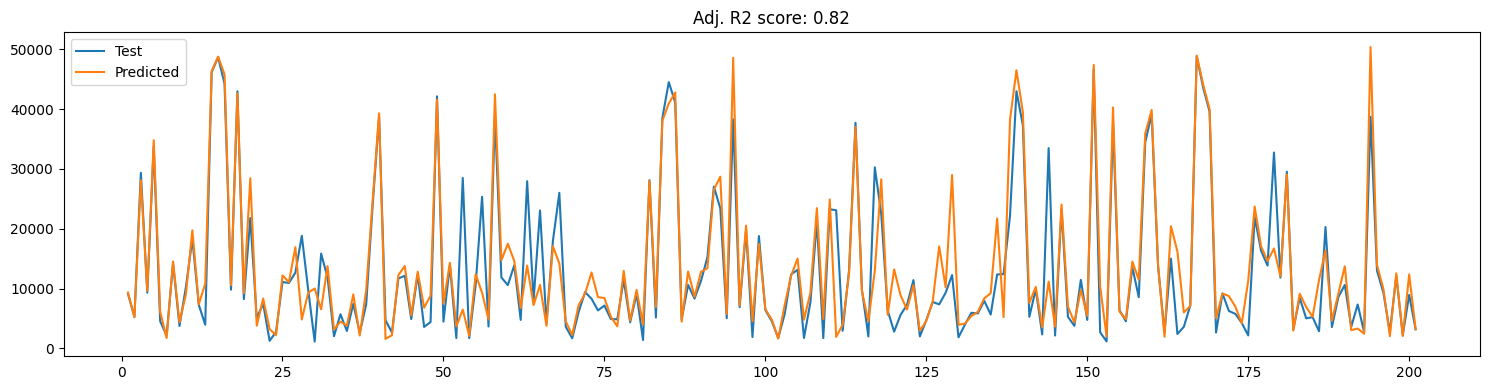

In [86]:
plt.figure(figsize=(15, 4))
sns.lineplot(x = np.arange(1, 202, 1), y = y_test.values, label = "Test")
sns.lineplot(x = np.arange(1, 202, 1), y = y_pred, label = "Predicted")
plt.legend()
plt.title(title)
plt.tight_layout()
plt.show()

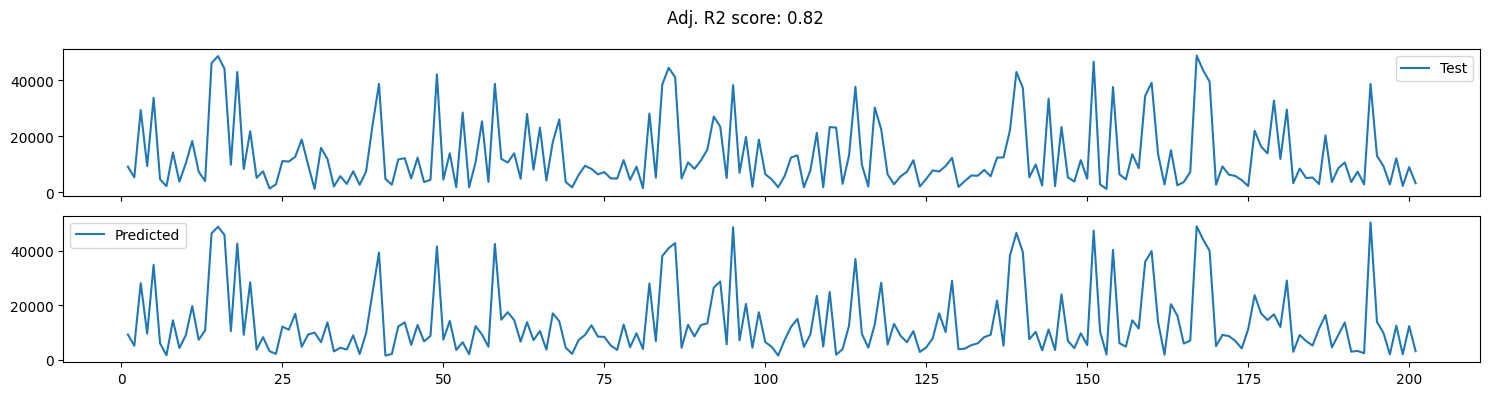

In [91]:
fig, ax = plt.subplots(2, 1, figsize=(15, 4), sharex=True)
sns.lineplot(x = np.arange(1, 202, 1), y = y_test.values, label = "Test", ax=ax[0])
sns.lineplot(x = np.arange(1, 202, 1), y = y_pred, label = "Predicted", ax=ax[1])
plt.legend()
fig.suptitle(title)
plt.tight_layout()
plt.show()

## Testing Model Prediction Ability

In [166]:
df[['age', 'bmi', 'smoker', 'charges']].sample(4, random_state=42).values

array([[45, 25.175, 'no', 9095.06825],
       [36, 30.02, 'no', 5272.1758],
       [64, 26.885, 'yes', 29330.98315],
       [46, 25.745, 'no', 9301.89355]], dtype=object)

In [170]:
input_df = pd.DataFrame([[45, 25.175, 'no']], columns=['age', 'bmi', 'smoker'])

In [172]:
input_df_nw = transformer.transform(input_df)

In [176]:
rf_model.predict(input_df_nw)

array([9320.8836667])

In [195]:
x,y = [2,3]

In [197]:
y

3